In [ ]:
import my_data_manager as mdm
import pandas as pd
import cluster_utils as cu

cat = mdm.load_cat("Data/galaxies_subhalos_zphot.cat")
halos = mdm.separate_halos(cat)
clusters, groups = mdm.separate_clusters(halos)
clusters = clusters[:678]

clean_clusters = [df[df.groupby("haloId")["haloId"].transform("count") > 3].reset_index(drop=True) for df in clusters]

N = 21

splus_clusters = [df[pd.to_numeric(df['mag_r'], errors = 'coerce') >= N].copy() for df in clusters]

clusters = cu.retag_noise(clusters)
splus_clusters = cu.retag_noise(splus_clusters)

cluster_samples = {
    "Raw": clusters,
    "Clean": clean_clusters,
    "SPLUS": splus_clusters
}

In [ ]:
import my_data_manager as mdm
import clustering_metrics as metrics

all_rows = []

for key in ["Raw", "Clean", "SPLUS"]:
    reported_results = mdm.load_results(f"Results/{key}_samples")
    df_times = metrics.compute_times(reported_results)

    for _, row in df_times.iterrows():
        all_rows.append({
            "Sample": key,
            "Method": row["Method"],
            "Mean": row["Mean"],
            "Std": row["Std"],
            "Summary": row["Summary"]
        })

df_all_times = pd.DataFrame(all_rows)

# --- PRINT TABLE ---
print(df_all_times.to_string(index=False))

In [ ]:
import gc
from sklearn.metrics import v_measure_score, normalized_mutual_info_score, adjusted_rand_score
import my_data_manager as mdm
import clustering_metrics as metrics

performance_metrics = {
    "Vmeasure": v_measure_score,
    "NMI": normalized_mutual_info_score,
    "ARI": adjusted_rand_score
}

keys = ["Raw", "Clean", "SPLUS"]

for metric_name, metric_func in performance_metrics.items():
    for key in keys:

        reuslts_dict = metrics.compute_performance_metric(mdm.load_results(f"Results/{key}_samples"), cluster_samples[key], metric_func)

        mdm.save_dict_to_excel(reuslts_dict, filename=f"Metrics/{metric_name}/{key}/results.xlsx")
        
        del reuslts_dict
        gc.collect()
    gc.collect()


In [ ]:
import gc
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import my_data_manager as mdm
import clustering_metrics as metrics

clustering_metrics = {
    "Silhouette": silhouette_score,
    "Calinski-Harabasz": calinski_harabasz_score,
    "Davies-Bouldin": davies_bouldin_score
}

keys = ["Raw", "Clean", "SPLUS"]

for metric_name, metric_func in clustering_metrics.items():
    for key in keys:

        reuslts_dict = metrics.compute_clustering_metric(mdm.load_results(f"Results/{key}_samples"), cluster_samples[key], metric_func)

        mdm.save_dict_to_excel(reuslts_dict, filename=f"Metrics/{metric_name}/{key}/results.xlsx")
        
        del reuslts_dict
        gc.collect()
    gc.collect()


In [ ]:
import numpy as np
import glob
import re

penalty_map = {
    "ARI": 0.0,                     # or -1.0 for absolute worst, but 0.0 is 'random'
    "NMI": 0.0,
    "Vmeasure": 0.0,                # also matches 'V measure'
    "V_measure": 0.0,
    "Silhouette": -1.0,             # -1.0 is the worst possible silhouette
    "Calinski-Harabasz": 0.0,       # Calinski-Harabasz: 0.0 is the minimum
    "Davies-Bouldin": 10.0          # Davies-Bouldin: lower is better. 10 is very poor (usually < 2).
}

keys = ["Raw", "Clean", "SPLUS"]

metrics = list(performance_metrics.keys()) + list(clustering_metrics.keys())

for key in keys:
    summary_data = {}
    for k in metrics:

        filename = f"{k}/{key}/results.xlsx"
        
        if not os.path.exists(filename):
            print(f"File not found: {filename}")
            continue
            
        # Load the entire Excel file. sheet_name=None returns a dict {sheet_name: DataFrame}
        excel_data = pd.read_excel(filename, sheet_name=None)


        penalty_value = penalty_map.get(k, 0.0)

        summary_rows = []

        for sheet_name, df_page in excel_data.items():

            data_values = pd.to_numeric(df_page.values.flatten(), errors='coerce')
            data_series = pd.Series(data_values)
            
            n_total = len(data_series)
            n_nans = data_series.isna().sum()
            fail_rate = (n_nans / n_total) if n_total > 0 else 0
            
            penalized_data = data_series.fillna(penalty_value)

            summary_rows.append({
                "Method": sheet_name,
                "Mean": np.mean(penalized_data),
                "Std": np.std(penalized_data),
                "Median": np.median(penalized_data),
                "Fail Rate": fail_rate
            })

        df_summary = pd.DataFrame(summary_rows)
            
        column_order = ["Method", "Mean", "Std", "Median", "Fail Rate"]
        df_summary = df_summary[column_order]
        
        output_name = f"Metrics/{k}/{key}/summary.xlsx"
        df_summary.to_excel(output_name, index=False)


In [ ]:
import gc
import cluster_utils as cu
import pickle
import os
import my_data_manager as mdm
import clustering_metrics as metrics

spatial_metrics = {
    "Distance": cu.calculate_distances,
    "Overlap": cu.calculate_overlaps,
    "N_Completeness": cu.calculate_overlap_completeness,
    "N_Purity": cu.calculate_overlap_purity,
    "N_F1": cu.calculate_overlap_f1

}

keys = ["Raw", "Clean", "SPLUS"]

for metric_name, metric_func in spatial_metrics.items():
    for key in keys:

        reuslts_dict = metrics.compute_spatial_metric(mdm.load_results(f"Results/{key}_samples"), cluster_samples[key], metric_func)

        directory = f"Metrics/{metric_name}/{key}"

        if directory:  # avoid issues if filename has no path
            os.makedirs(directory, exist_ok=True)

        with open(f"Metrics/{metric_name}/{key}/results.pkl", "wb") as f:
            pickle.dump(reuslts_dict, f)
        
        del reuslts_dict
        gc.collect()
    gc.collect()


In [ ]:
import gc
import cluster_utils as cu
import pickle
import my_data_manager as mdm
import clustering_metrics as metrics

membership_metrics = {
    "M_Completeness": cu.calculate_membership_completeness,
    "M_Purity": cu.calculate_membership_purity,
    "M_F1": cu.calculate_membership_f1
}

keys = ["Raw", "Clean", "SPLUS"]

for metric_name, metric_func in membership_metrics.items():
    for key in keys:

        reuslts_dict = metrics.compute_membership_metric(mdm.load_results(f"Results/{key}_samples"), cluster_samples[key], metric_func)

        directory = f"Metrics/{metric_name}/{key}"

        if directory:  # avoid issues if filename has no path
            os.makedirs(directory, exist_ok=True)

        with open(f"Metrics/{metric_name}/{key}/results.pkl", "wb") as f:
            pickle.dump(reuslts_dict, f)
        
        del reuslts_dict
        gc.collect()
    gc.collect()


In [ ]:
import pickle
import numpy as np
import os
import clustering_metrics as metrics

# --- CONFIGURATION ---
partitioning_methods = ["ML_Kmeans", "ML_GMM", "ML_Aglomerative", "ML_Affinity"]
methods = sorted([
    "CALSAGOS", "DSP", "ML_DBSCAN", "ML_HDBSCAN", "ML_Optics",
    "ML_Kmeans", "ML_Affinity", "ML_GMM", "ML_Aglomerative"
])

keys = ["Raw", "Clean", "SPLUS"]
modes = ["satellites", "center"]

metrics_to_process = [
    "M_Completeness", "M_Purity", "M_F1",
    "N_Completeness", "N_Purity", "N_F1"
]

for key in keys:
    has_noise = (key != "Clean")

    for metric in metrics_to_process:
        input_pkl = f"Metrics/{metric}/{key}/results.pkl"
        if not os.path.exists(input_pkl):
            continue

        with open(input_pkl, "rb") as f:
            data = pickle.load(f)

        for mode in modes:
            gradients = {}
            grad_averages = {}
            grad_deviations = {}

            for method, halo_dict in data.items():
                is_part = any(pm in method for pm in partitioning_methods)

                grads = []
                for execution_list in halo_dict.values():
                    for single_matrix in execution_list:
                        g = metrics.calculate_pred_gradient(single_matrix, mode, has_noise, is_part)
                        grads.append(g)

                average = np.mean(grads, axis=0) * 100
                std = np.std(grads, axis=0) * 100

                gradients[method] = grads
                grad_averages[method] = average
                grad_deviations[method] = std

            directory = f"Metrics/{metric}/{key}"
            os.makedirs(directory, exist_ok=True)

            with open(f"{directory}/{mode}_pred_gradients.pkl", "wb") as f:
                pickle.dump(gradients, f)

            with open(f"{directory}/{mode}_pred_gradient_AVG.pkl", "wb") as f:
                pickle.dump(grad_averages, f)

            with open(f"{directory}/{mode}_pred_gradient_STD.pkl", "wb") as f:
                pickle.dump(grad_deviations, f)

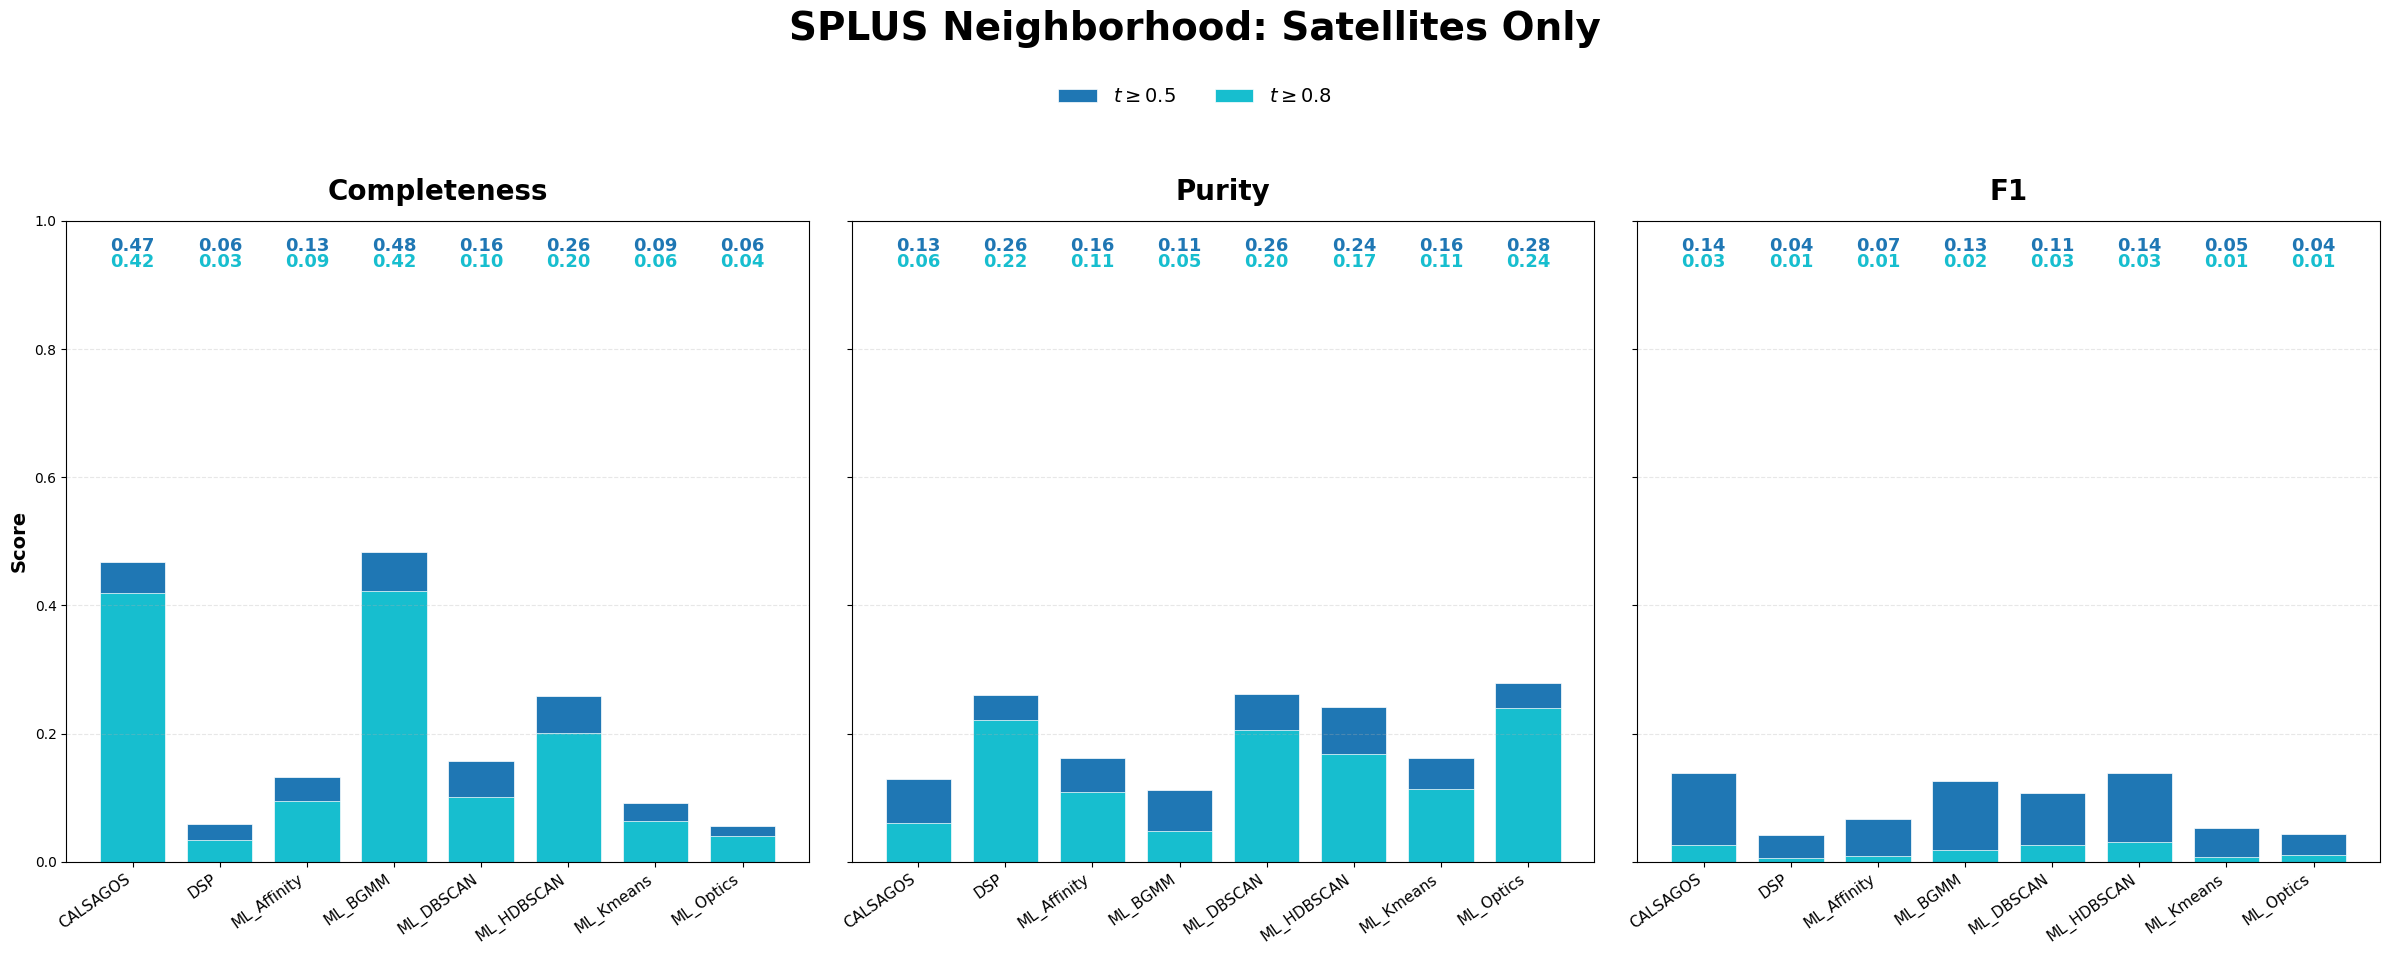

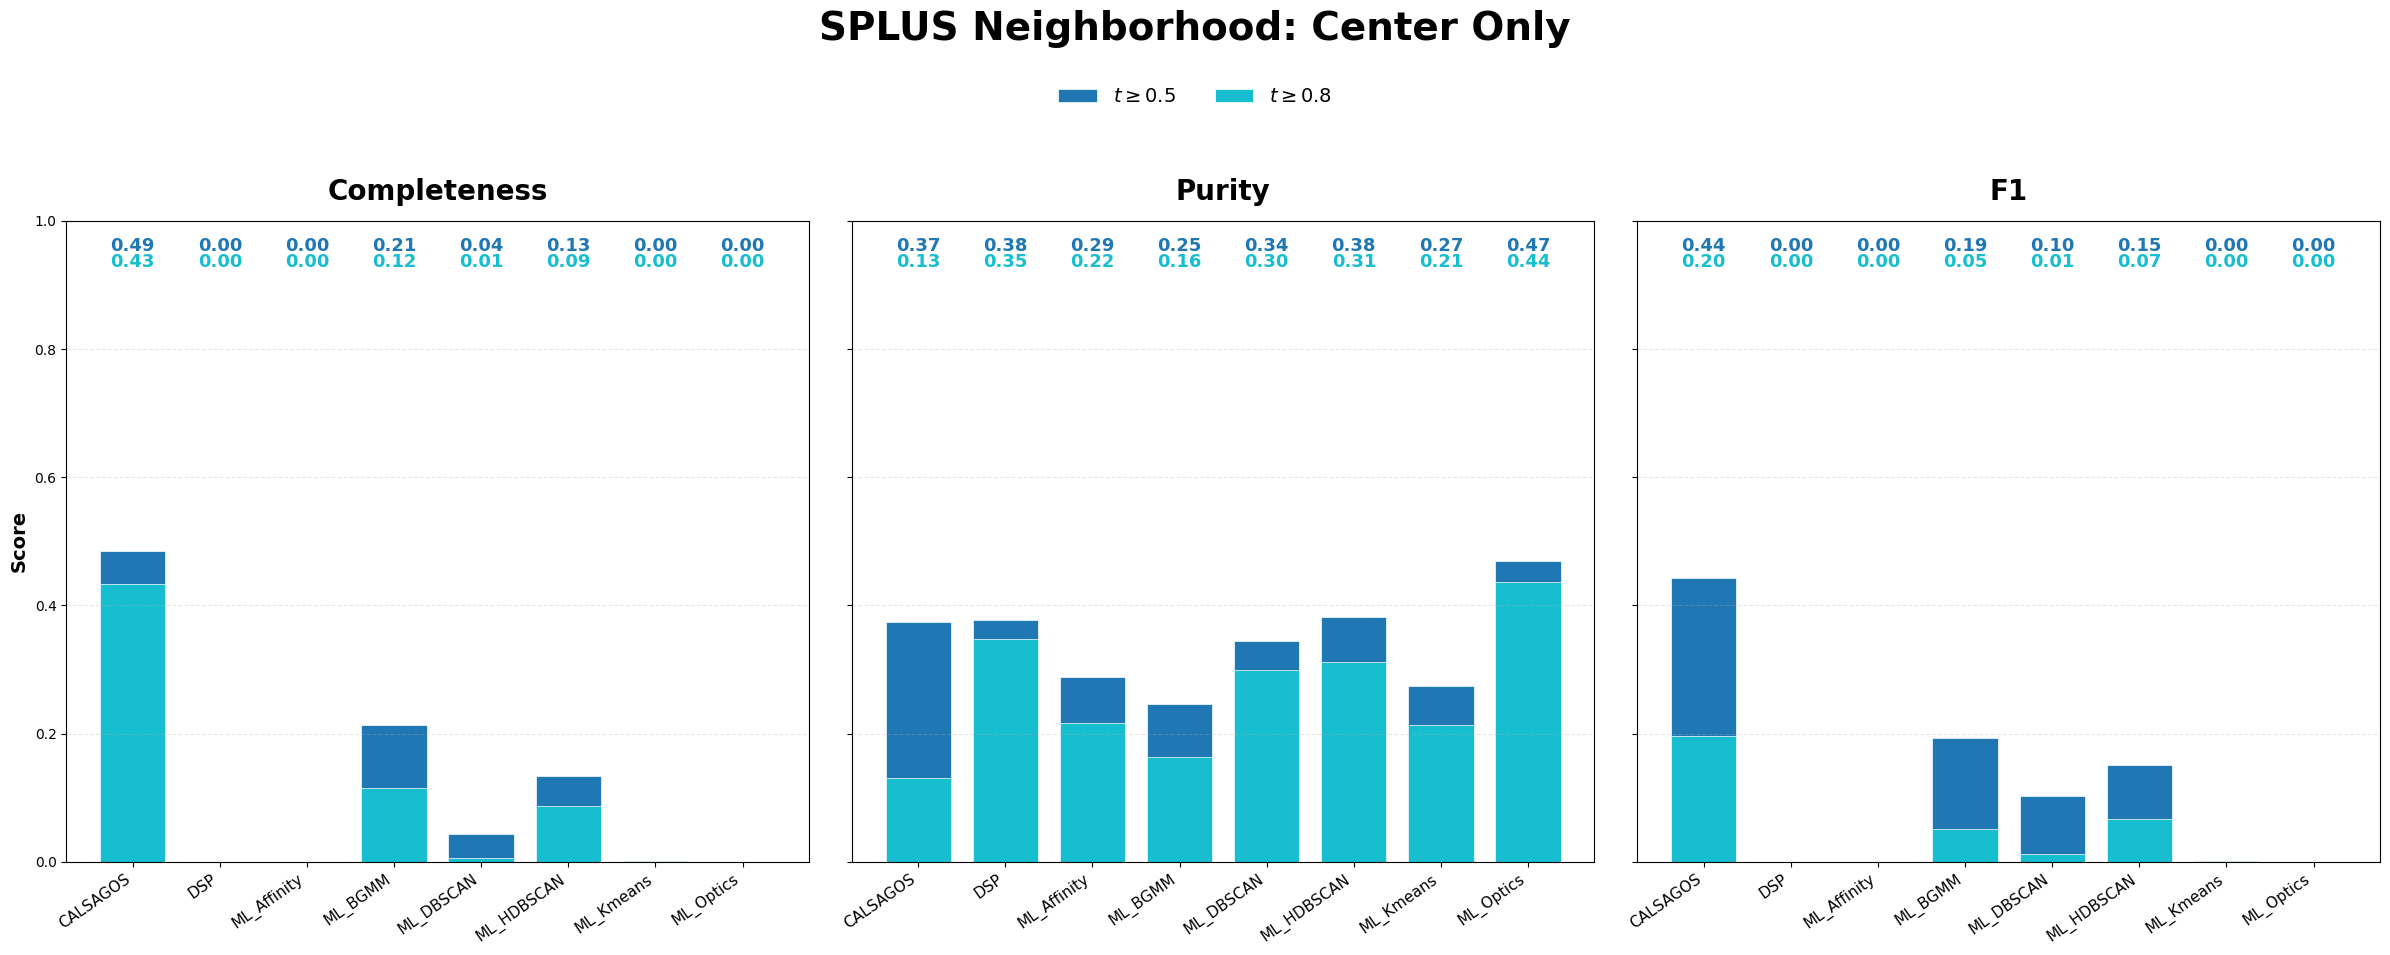

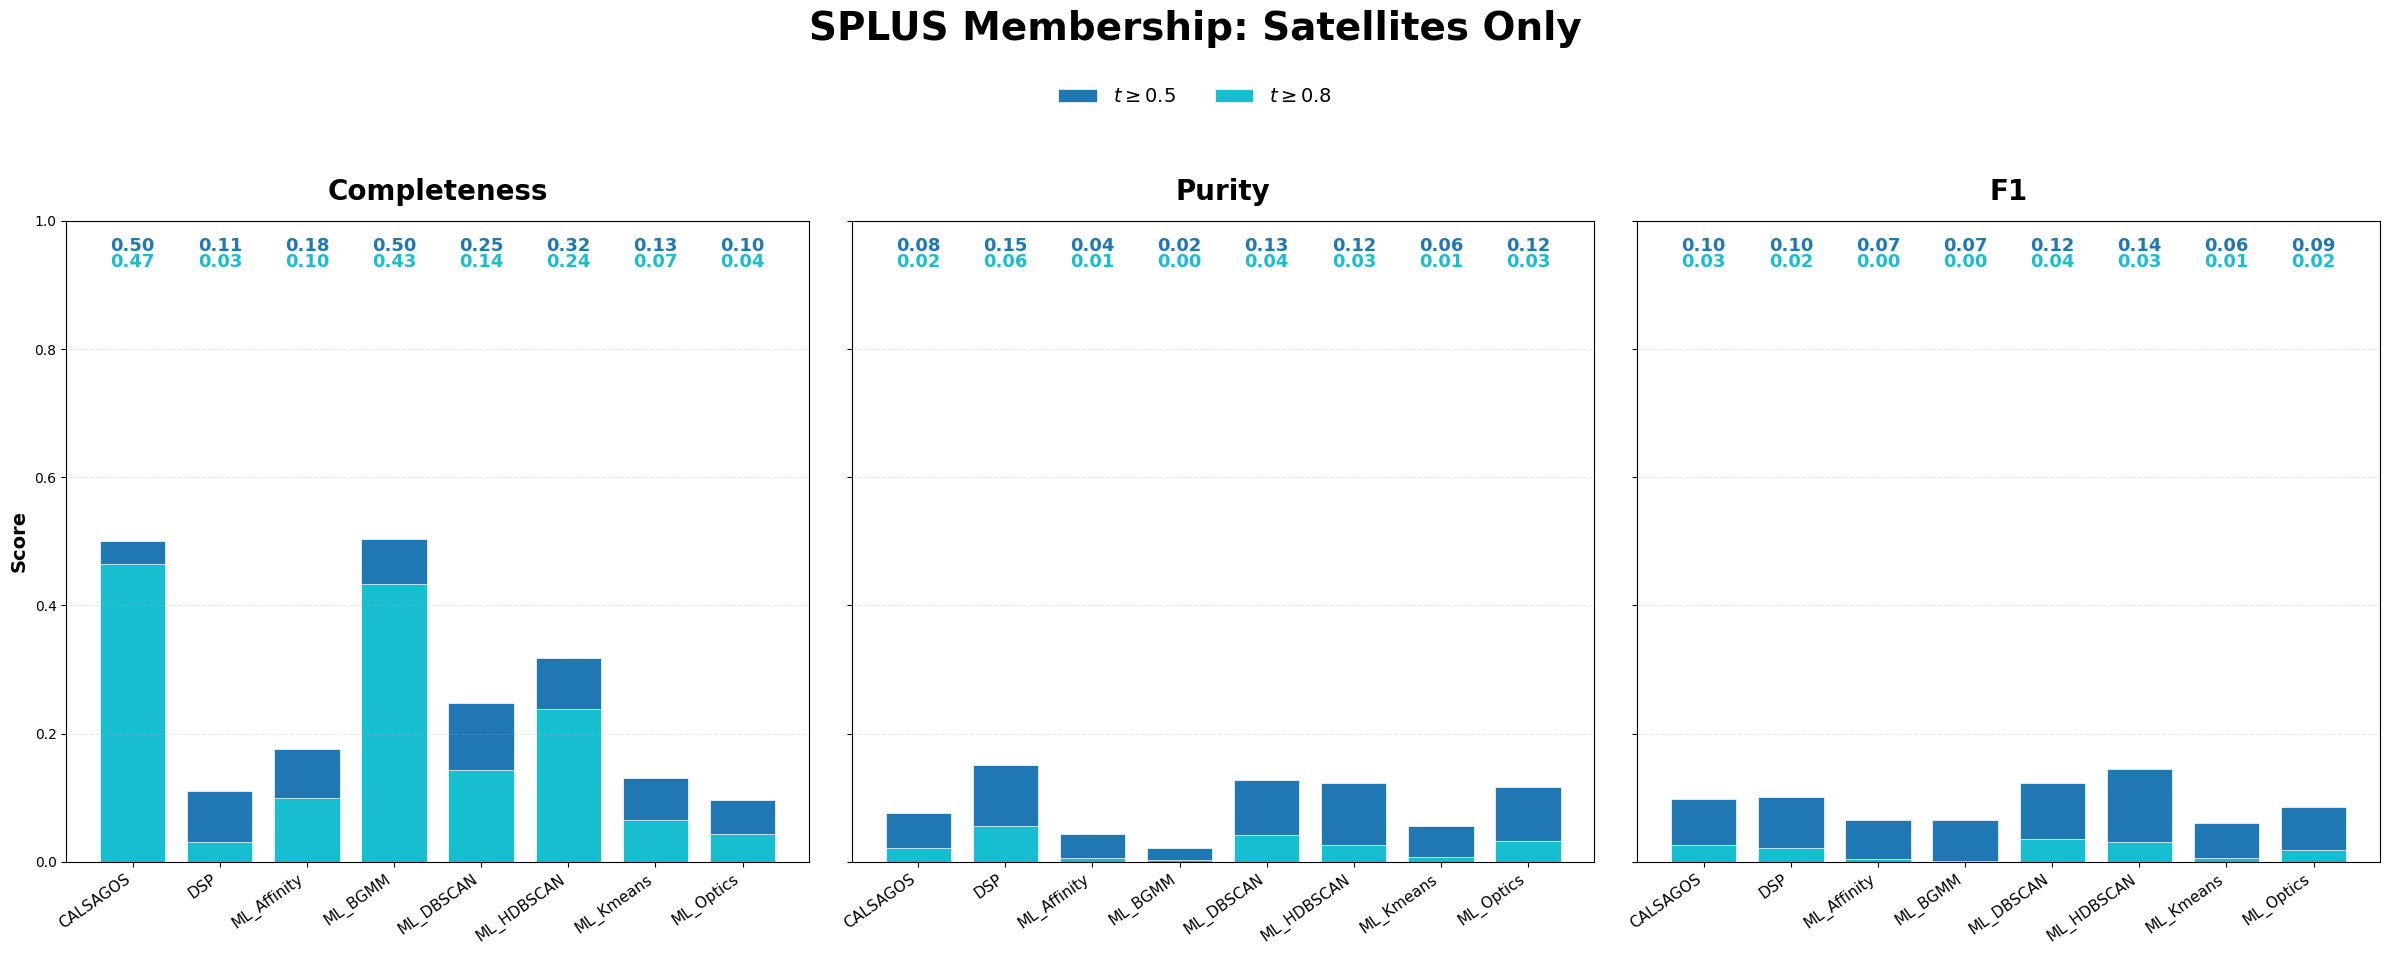

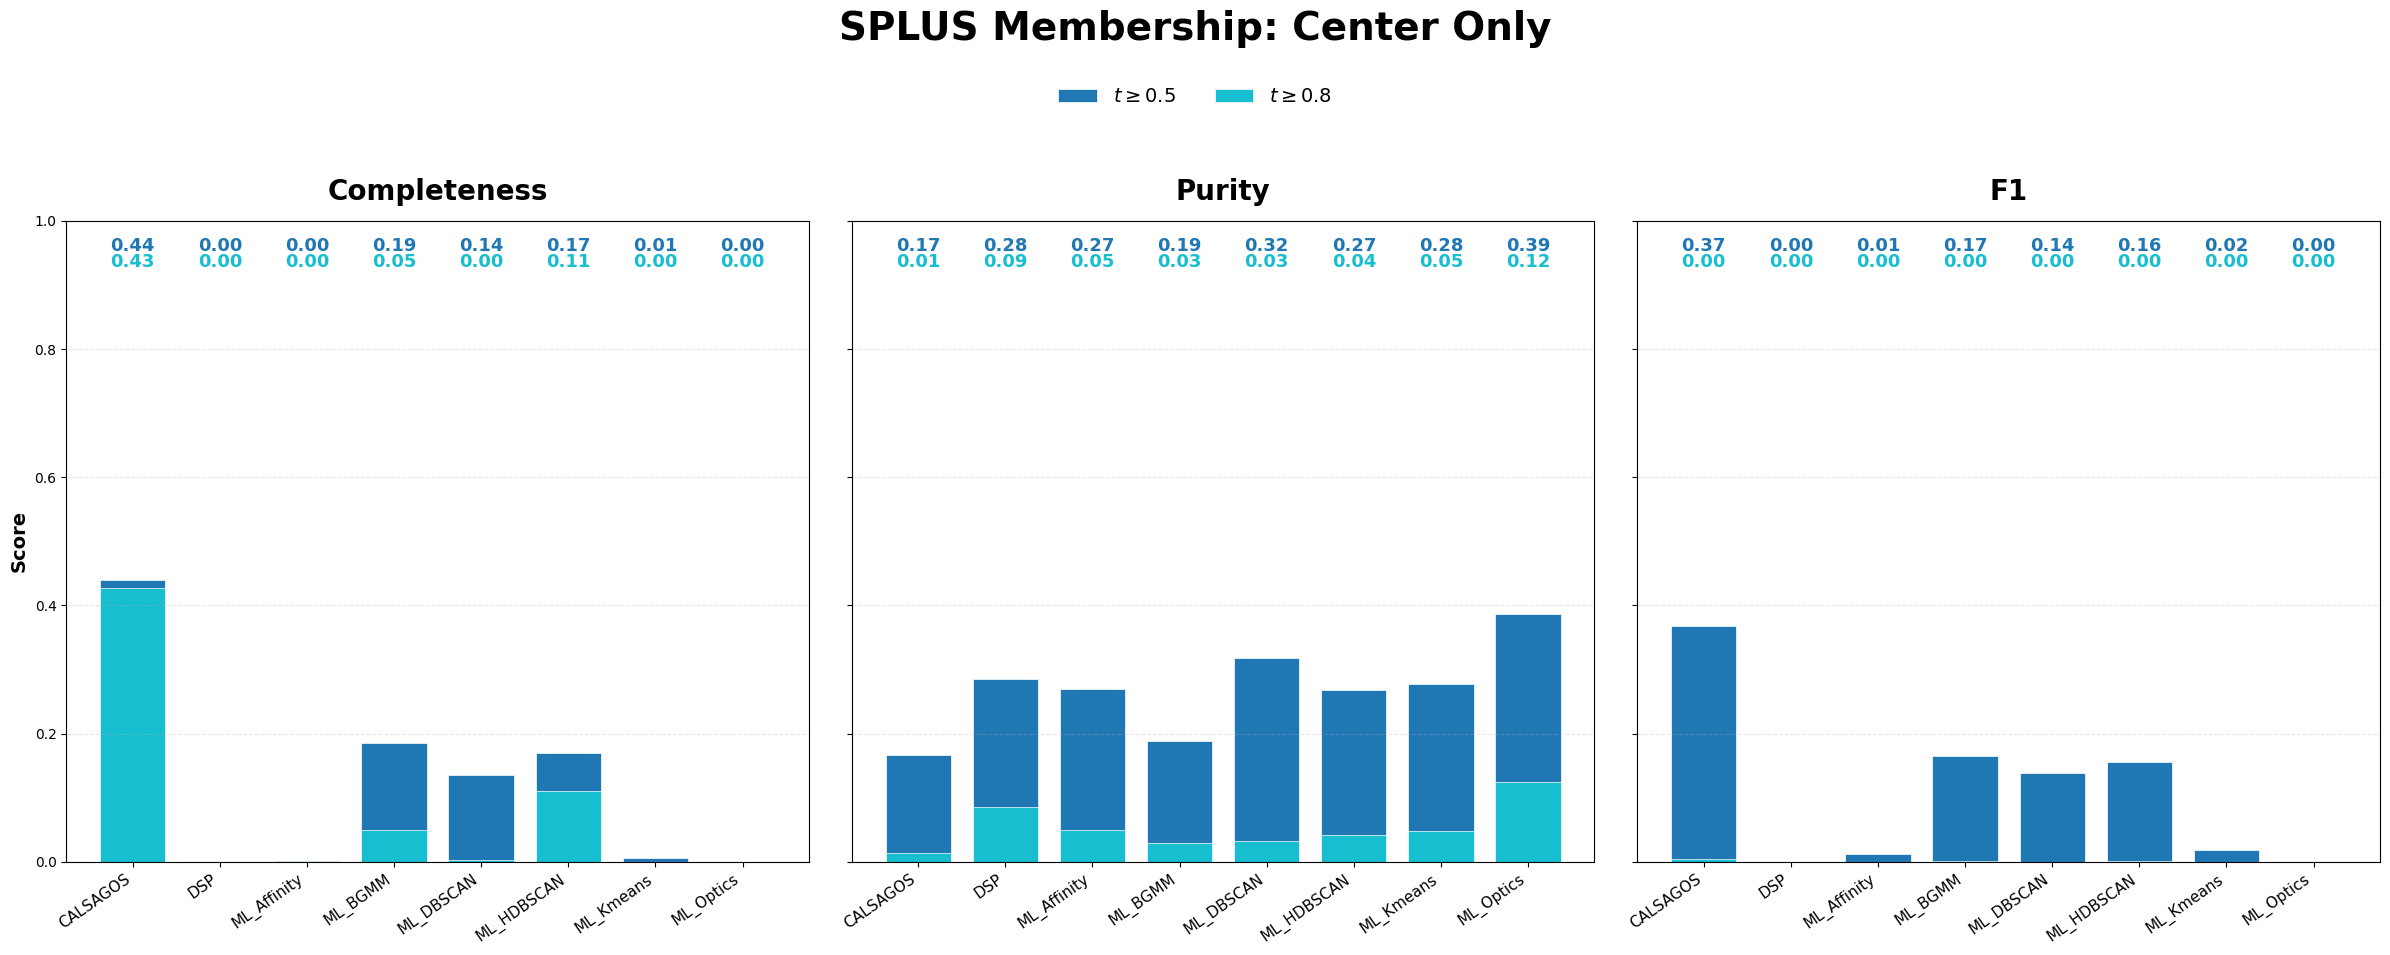

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plot_maker as pm

# --- CONFIG ---
keys = ["SPLUS"]
modes = ["satellites", "center"]

metric_trios = [
    ("Neighborhood", ["N_Completeness", "N_Purity", "N_F1"]),
    ("Membership", ["M_Completeness", "M_Purity", "M_F1"])
]

methods_order = sorted([
    "CALSAGOS", "DSP", "ML_DBSCAN", "ML_HDBSCAN", "ML_Optics",
    "ML_Kmeans", "ML_Affinity", "ML_BGMM", "ML_Aglomerative"
])

titles_map = {
    "all": "All Data",
    "no-noise": "No Single Galaxies",
    "satellites": "Satellites Only",
    "center": "Center Only"
}

thresholds = [0.5, 0.8]


# --- PLOT ---
for key in keys:
    for trio_name, metrics in metric_trios:
        for mode in modes:

            fig, axes = plt.subplots(1, 3, figsize=(24, 10), sharey=True)
            something_plotted = False

            for i, metric in enumerate(metrics):
                file_path = f"Metrics/{metric}/{key}/{mode}_pred_gradient_AVG.pkl"

                if not os.path.exists(file_path):
                    print(f"Missing: {file_path}")
                    continue

                with open(file_path, "rb") as f:
                    data = pickle.load(f)

                df = pd.DataFrame(data).T

                fig, ax, plotted = pm.gradient_bar_plot(
                    df=df,
                    metric_name=metric,
                    thresholds=thresholds,
                    methods_order=methods_order,
                    ax=axes[i],
                    colors=None,   # uses DEFAULT_PALETTE
                    ymax=1,
                    text_top_margin=0.025,
                    text_gap=0.025,
                    show_ylabel=(i == 0),
                    bar_width=0.75
                )

                if plotted:
                    something_plotted = True

            if something_plotted:
                fig.suptitle(
                    f"{key.upper()} {trio_name}: {titles_map[mode]}",
                    fontsize=28,
                    fontweight="bold",
                    y=0.98
                )

                handles, labels = axes[0].get_legend_handles_labels()
                unique = dict(zip(labels, handles))

                fig.legend(
                    unique.values(),
                    unique.keys(),
                    loc="upper center",
                    bbox_to_anchor=(0.5, 0.92),
                    ncol=len(thresholds),
                    frameon=False,
                    fontsize=14
                )

                plt.tight_layout(rect=[0, 0.03, 1, 0.88])

                save_dir = f"Images/{key}/{trio_name}/"
                os.makedirs(save_dir, exist_ok=True)

                thresholds_tag = "_".join(str(t).replace(".", "") for t in thresholds)
                save_path = f"{save_dir}{mode}_t{thresholds_tag}.png"

                plt.savefig(save_path, dpi=300, bbox_inches="tight")
                plt.show()
            else:
                plt.close(fig)

In [5]:
import numpy as np
import pickle
import os
from scipy.stats import spearmanr

# --- CONFIGURATION ---
keys = ["Raw", "Clean", "SPLUS"]
source_metrics = ["N_F1", "M_F1"]
dist_metric = "Distance"
correlation_metric_name = "S_Correlation"

all_methods = sorted([
    "CALSAGOS", "DSP", "ML_DBSCAN", "ML_HDBSCAN", "ML_Optics",
    "ML_Kmeans", "ML_Affinity", "ML_GMM", "ML_Aglomerative"
])

def process_inhomogeneous_matrices(matrix_list, has_noise):
    """
    Handles a list of 10 matrices where the number of columns varies.
    Returns a single flattened array of all 'real halo' entries.
    """
    flat_values = []
    for exec_matrix in matrix_list:
        m_arr = np.array(exec_matrix)
        # Slicing: Strip Row 0 (Noise) if applicable
        m_real = m_arr[1:, :] if has_noise else m_arr
        flat_values.extend(m_real.flatten())
    return np.array(flat_values)

# --- EXECUTION ---
for metric in source_metrics:
    for key in keys:
        has_noise = (key != "Clean")
        metric_path = f"Metrics/{metric}/{key}/results.pkl"
        dist_path = f"Metrics/{dist_metric}/{key}/results.pkl"
        
        if not os.path.exists(metric_path) or not os.path.exists(dist_path):
            continue
            
        with open(metric_path, "rb") as f: m_data = pickle.load(f)
        with open(dist_path, "rb") as f: d_data = pickle.load(f)

        method_results = {}
        for method in all_methods:
            if method not in m_data or method not in d_data: continue
            
            all_m = []
            all_d = []
            
            # h_id is the cluster ID
            for h_id in m_data[method].keys():
                if h_id not in d_data[method]: continue
                
                # Extract and flatten all 10 executions for this specific cluster
                m_flat = process_inhomogeneous_matrices(m_data[method][h_id], has_noise)
                d_flat = process_inhomogeneous_matrices(d_data[method][h_id], has_noise)
                
                # Check that they match (they should, as they represent the same True Halos)
                if len(m_flat) == len(d_flat):
                    all_m.extend(m_flat)
                    all_d.extend(d_flat)

            # Final correlation for the method across the entire 700-cluster pool
            all_m = np.array(all_m)
            all_d = np.array(all_d)
            
            # Spearman mask: F1 > 0 and Distance >= 0
            mask = (all_m > 0) & (all_d >= 0)
            
            if np.sum(mask) >= 10: # Increased threshold for statistical significance
                rho, p = spearmanr(all_d[mask], all_m[mask])
                method_results[method] = {"rho": rho, "p": p}
                print(f"[{key} | {metric}] {method}: rho={rho:.3f}")

        # SAVE
        out_dir = f"Metrics/{correlation_metric_name}/{key}"
        os.makedirs(out_dir, exist_ok=True)
        save_path = f"{out_dir}/no-noise_{metric}_vs_Dist.pkl"
        with open(save_path, "wb") as f:
            pickle.dump(method_results, f)

[Raw | N_F1] CALSAGOS: rho=-0.419
[Raw | N_F1] DSP: rho=-0.346
[Raw | N_F1] ML_Affinity: rho=-0.462
[Raw | N_F1] ML_Aglomerative: rho=-0.552
[Raw | N_F1] ML_DBSCAN: rho=-0.613
[Raw | N_F1] ML_GMM: rho=-0.371
[Raw | N_F1] ML_HDBSCAN: rho=-0.512
[Raw | N_F1] ML_Kmeans: rho=-0.560
[Raw | N_F1] ML_Optics: rho=-0.397
[Clean | N_F1] CALSAGOS: rho=-0.587
[Clean | N_F1] DSP: rho=-0.371
[Clean | N_F1] ML_Affinity: rho=-0.513
[Clean | N_F1] ML_Aglomerative: rho=-0.572
[Clean | N_F1] ML_DBSCAN: rho=-0.632
[Clean | N_F1] ML_GMM: rho=-0.480
[Clean | N_F1] ML_HDBSCAN: rho=-0.597
[Clean | N_F1] ML_Kmeans: rho=-0.577
[Clean | N_F1] ML_Optics: rho=-0.460
[SPLUS | N_F1] CALSAGOS: rho=-0.452
[SPLUS | N_F1] DSP: rho=-0.325
[SPLUS | N_F1] ML_Affinity: rho=-0.519
[SPLUS | N_F1] ML_Aglomerative: rho=-0.525
[SPLUS | N_F1] ML_DBSCAN: rho=-0.595
[SPLUS | N_F1] ML_GMM: rho=-0.452
[SPLUS | N_F1] ML_HDBSCAN: rho=-0.491
[SPLUS | N_F1] ML_Kmeans: rho=-0.543
[SPLUS | N_F1] ML_Optics: rho=-0.340
[Raw | M_F1] CALSAGOS:

In [49]:
import numpy as np
import pickle
import os

# --- CONFIGURATION ---
keys = ["Raw", "Clean", "SPLUS"]
source_metrics = ["N_F1", "M_F1"]
dist_metric = "Distance"
all_methods = sorted(["CALSAGOS", "DSP", "ML_DBSCAN", "ML_HDBSCAN", "ML_Optics", "ML_Kmeans", "ML_Affinity", "ML_GMM", "ML_Aglomerative"])

for metric in source_metrics:
    for key in keys:
        has_noise = (key != "Clean")
        m_path = f"Metrics/{metric}/{key}/results.pkl"
        d_path = f"Metrics/{dist_metric}/{key}/results.pkl"
        
        if not os.path.exists(m_path) or not os.path.exists(d_path): continue
            
        with open(m_path, "rb") as f: m_data = pickle.load(f)
        with open(d_path, "rb") as f: d_data = pickle.load(f)

        method_scatter_data = {}
        for method in all_methods:
            if method not in m_data or method not in d_data: continue
            
            all_m, all_d = [], []
            for h_id in m_data[method].keys():
                if h_id not in d_data[method]: continue
                
                # --- FIX: Iterate through the 10 executions separately ---
                # This prevents the inhomogeneous NumPy error
                for exec_idx in range(len(m_data[method][h_id])):
                    m_exec = np.array(m_data[method][h_id][exec_idx])
                    d_exec = np.array(d_data[method][h_id][exec_idx])
                    
                    # Slice for no-noise (Remove Row 0 if Raw/SPLUS)
                    m_real = m_exec[1:, :] if has_noise else m_exec
                    d_real = d_exec[1:, :] if has_noise else d_exec
                    
                    # Flatten the matrices for this execution
                    m_flat = m_real.flatten()
                    d_flat = d_real.flatten()
                    
                    # Only take points where algorithm found a cluster (F1 > 0)
                    mask = m_flat > 0
                    all_m.extend(m_flat[mask])
                    all_d.extend(d_flat[mask])
            
            method_scatter_data[method] = {"dist": np.array(all_d), "f1": np.array(all_m)}

        out_dir = f"Metrics/S_Correlation/{key}"
        os.makedirs(out_dir, exist_ok=True)
        save_path = f"{out_dir}/scatter_{metric}_vs_Dist.pkl"
        with open(save_path, "wb") as f:
            pickle.dump(method_scatter_data, f)
        print(f"Saved scatter data: {save_path}")

Saved scatter data: Metrics/S_Correlation/Raw/scatter_N_F1_vs_Dist.pkl
Saved scatter data: Metrics/S_Correlation/Clean/scatter_N_F1_vs_Dist.pkl
Saved scatter data: Metrics/S_Correlation/SPLUS/scatter_N_F1_vs_Dist.pkl
Saved scatter data: Metrics/S_Correlation/Raw/scatter_M_F1_vs_Dist.pkl
Saved scatter data: Metrics/S_Correlation/Clean/scatter_M_F1_vs_Dist.pkl
Saved scatter data: Metrics/S_Correlation/SPLUS/scatter_M_F1_vs_Dist.pkl


RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

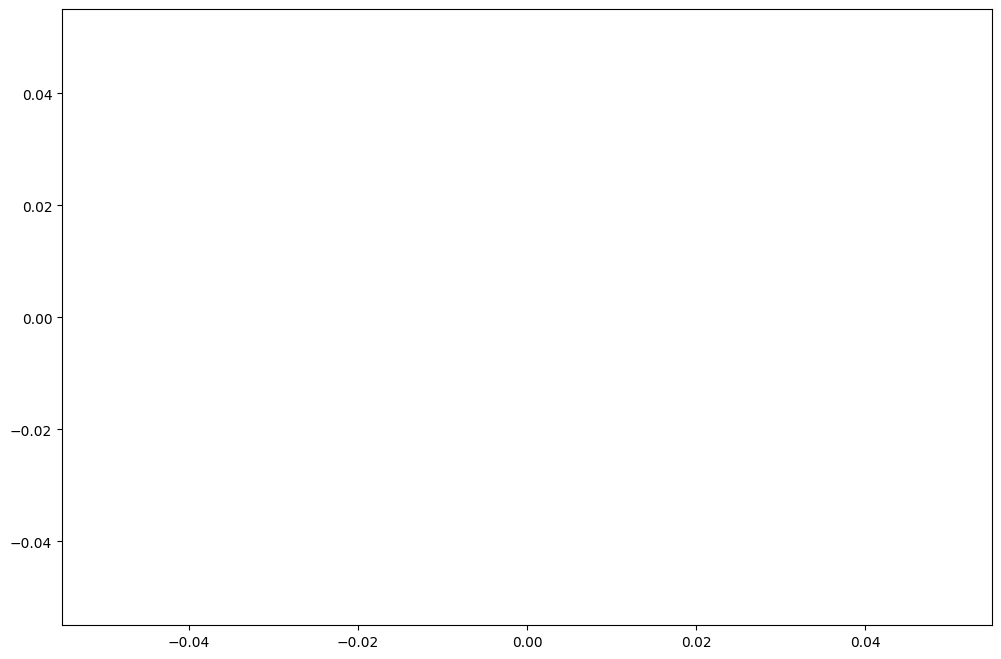

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import numpy as np
from scipy.stats import spearmanr

# --- 1. CONFIGURATION ---
keys = ["Raw", "Clean", "SPLUS"]
source_metrics = ["N_F1", "M_F1"]
titles_map = {"N_F1": "Neighborhood Quality", "M_F1": "Membership Accuracy"}
key_titles = {"Raw": "Raw Data", "Clean": "Clean Data", "SPLUS": "S+LUS Data"}

save_dir = "Images/Centering_Degradation_Final"
os.makedirs(save_dir, exist_ok=True)

for metric in source_metrics:
    for key in keys:
        plt.figure(figsize=(12, 8))
        ax = plt.gca()
        
        file_path = f"Metrics/S_Correlation/{key}/scatter_{metric}_vs_Dist.pkl"
        if not os.path.exists(file_path): continue
            
        with open(file_path, "rb") as f:
            data = pickle.load(f)
            
        all_dataset_dists = []
            
        for method in sorted(data.keys()):
            dists_deg = data[method]["dist"]
            f1s = data[method]["f1"]
            
            if len(dists_deg) < 10: continue
            all_dataset_dists.extend(dists_deg)
            
            # Subsampling for performance
            if len(dists_deg) > 2000:
                idx = np.random.choice(len(dists_deg), 2000, replace=False)
                d_plot, f_plot = dists_deg[idx], f1s[idx]
            else:
                d_plot, f_plot = dists_deg, f1s
            
            rho, _ = spearmanr(dists_deg, f1s)
            label_text = f"{method} (ρ = {rho:.2f})"
            
            sns.regplot(x=d_plot, y=f_plot, scatter=False, ax=ax, label=label_text, 
                        lowess=True, ci=None, line_kws={"linewidth": 3, "alpha": 0.8})

        # --- STATISTICAL MARKERS (SHADED) ---
        if all_dataset_dists:
            all_dataset_dists = np.array(all_dataset_dists)
            med_val = np.median(all_dataset_dists)
            std_val = np.std(all_dataset_dists)
            
            # Median as a dotted (point) line
            ax.axvline(med_val, color='black', linestyle=':', linewidth=2.5, 
                       label=f"Median Offset: {med_val:.3f}°", zorder=5)
            
            # Standard Deviation as a shaded region (from 0 to Mean + 1 Std)
            # Or you can do Mean-Std to Mean+Std if you prefer. 
            # Here we shade the 'Typical Error Zone' up to 1-sigma.
            ax.axvspan(0, med_val + std_val, color='gray', alpha=0.15, 
                       label=r"1$\sigma$ Uncertainty Zone", zorder=1)

        # --- STYLING ---
        full_title = f"{titles_map[metric]} vs. Centering Offset\n(Dataset: {key_titles[key]})"
        ax.set_title(full_title, fontsize=18, fontweight='bold', pad=20)
        
        ax.set_xlabel("Centering Offset [Degrees]", fontsize=14)
        ax.set_xlim(0, 0.8) 
        
        ax.set_ylabel(f"{titles_map[metric]} (F1 Score)", fontsize=14)
        ax.set_ylim(0, 1.05)
        
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), 
                  title=r"Spearman $\rho$", title_fontsize=12, frameon=True)

        plt.tight_layout()
        filename = f"Final_Degradation_{metric}_{key}.png"
        plt.savefig(f"{save_dir}/{filename}", dpi=300, bbox_inches='tight')
        print(f"Graph generated: {filename}")
        plt.show()

In [7]:
import numpy as np
import pickle
import os
import astro_utils as au
from astropy.stats import biweight_location

# --- CONFIGURATION ---
partitioning_methods = ["ML_Kmeans", "ML_GMM", "ML_Aglomerative", "ML_Affinity"]
keys = ["Raw", "Clean", "SPLUS"]
source_metrics = ["N_F1", "M_F1"]
profiling_name = "Radial_Halo_Proficiency"

def get_halo_radial_distances(sample_df):
    
    numeric_cols = ["RA", "DEC", "z_app", "log(m_200)"]
    for col in numeric_cols:
        sample_df[col] = pd.to_numeric(sample_df[col], errors='coerce')
    
    ra_clus = biweight_location(sample_df["RA"].dropna().values)
    dec_clus = biweight_location(sample_df["DEC"].dropna().values)
    z_clus = biweight_location(sample_df["z_app"].dropna().values)
    
    logM200 = sample_df["log(m_200)"].iloc[0] 
    r200_val = au.get_r_200(logM200, z_clus)
    
    sample_df['haloId_str'] = sample_df['haloId'].astype(str)
    
    real_halos = sample_df[~sample_df['haloId_str'].isin(["-1", "-1.0"])].copy()
    
    if real_halos.empty:
        return np.array([])

    halo_groups = real_halos.groupby('haloId_str').agg({
        'RA': 'mean', 
        'DEC': 'mean'
    }).sort_index() 
    
    r_norms = []
    for _, row in halo_groups.iterrows():
        x_mpc, y_mpc = au.gal_Mpc_coords(row['RA'], row['DEC'], z_clus, ra_clus, dec_clus)
        r_proj = np.sqrt(x_mpc**2 + y_mpc**2)
        r_norms.append(r_proj / r200_val)
        
    return np.array(r_norms)

for metric in source_metrics:
    for key in keys:
        m_path = f"Metrics/{metric}/{key}/results.pkl"
        if not os.path.exists(m_path): continue
        with open(m_path, "rb") as f: 
            m_data = pickle.load(f)

        lookup = {str(df['firstHaloInFOFGroupId'].iloc[0]): df for df in cluster_samples[key]}
        
        method_radial_data = {}
        for method, halos_dict in m_data.items():
            is_part = any(pm in method for pm in partitioning_methods)
            all_r, all_f1 = [], []
            
            for h_id, f1_matrix_list in halos_dict.items():
                h_id_str = str(h_id)
                if h_id_str not in lookup: continue
                
                df = lookup[h_id_str]
                r_distances = get_halo_radial_distances(df) 
                n_phys = len(r_distances)
                if n_phys == 0: continue

                # Determine noise row index
                unique_ids = np.unique(df['haloId'].astype(str))
                noise_indices = [i for i, val in enumerate(unique_ids) if val in ["-1", "-1.0"]]
                
                exec_best_matches = []
                for f1_mat in f1_matrix_list:
                    f1_arr = np.array(f1_mat)
                    
                    # Columns: Strip noise col (0) if not partitioning
                    actual_clusters = f1_arr if is_part else f1_arr[:, 1:]
                    
                    # Rows: Remove the noise row found earlier
                    if noise_indices:
                        clean_rows = np.delete(actual_clusters, noise_indices, axis=0)
                    else:
                        clean_rows = actual_clusters
                    
                    # --- THE FIX ---
                    # Check if we have columns left. If not, best match is 0.0
                    if clean_rows.shape[1] > 0:
                        if clean_rows.shape[0] == n_phys:
                            exec_best_matches.append(np.max(clean_rows, axis=1))
                    else:
                        # Penalty for zero-cluster detection
                        exec_best_matches.append(np.zeros(n_phys))
                
                if exec_best_matches:
                    f1_mean_best = np.mean(exec_best_matches, axis=0)
                    all_r.extend(r_distances)
                    all_f1.extend(f1_mean_best)

            method_radial_data[method] = {"r": np.array(all_r), "f1": np.array(all_f1)}

        # Save
        save_dir = f"Metrics/Radial_Halo_Proficiency/{key}"
        os.makedirs(save_dir, exist_ok=True)
        with open(f"{save_dir}/{metric}_no_noise_radial.pkl", "wb") as f:
            pickle.dump(method_radial_data, f)

Saved: Images/Radial_Proficiency/Raw_N_F1_Radial.png


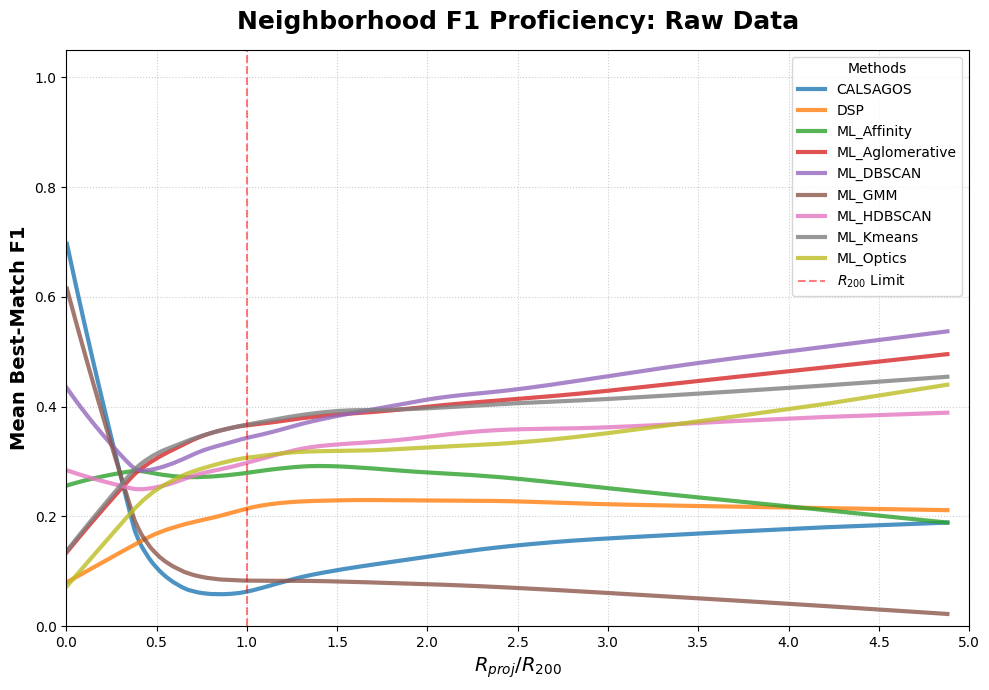

Saved: Images/Radial_Proficiency/Clean_N_F1_Radial.png


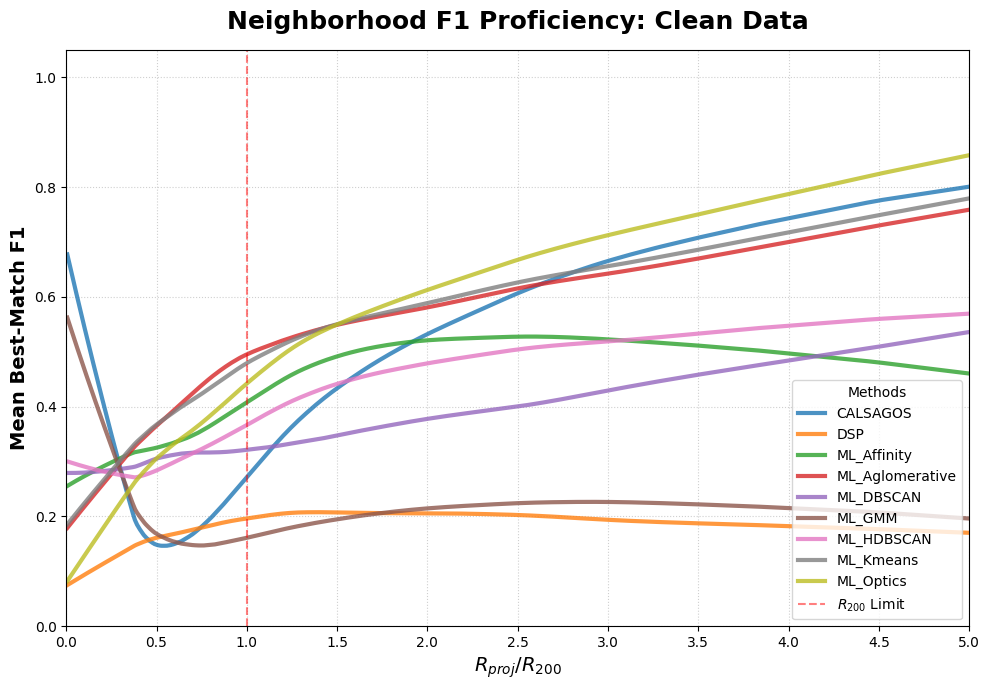

Saved: Images/Radial_Proficiency/SPLUS_N_F1_Radial.png


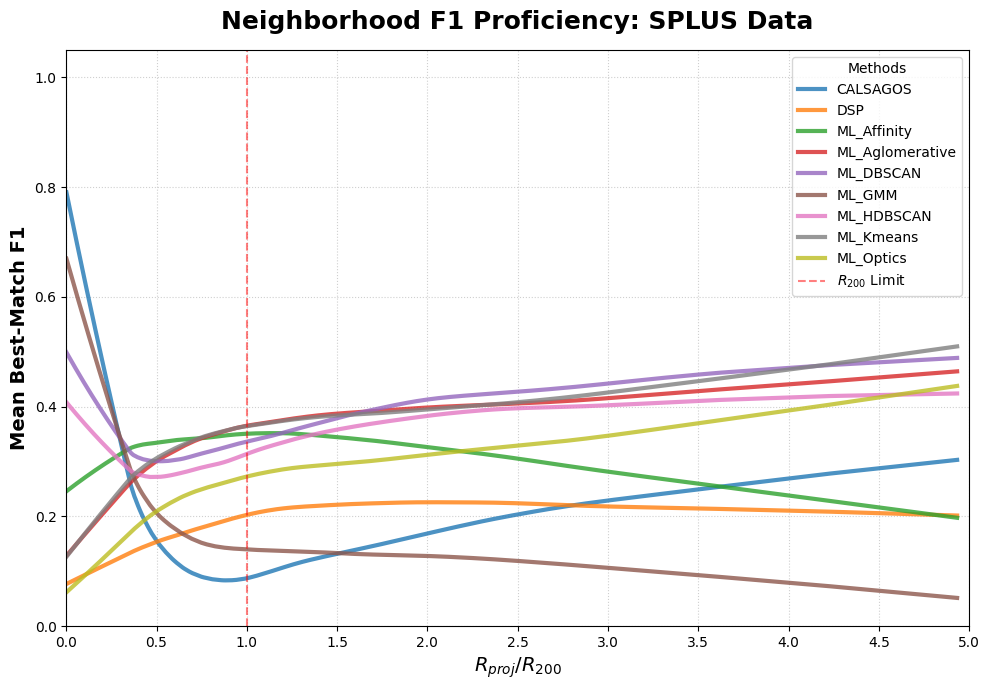

Saved: Images/Radial_Proficiency/Raw_M_F1_Radial.png


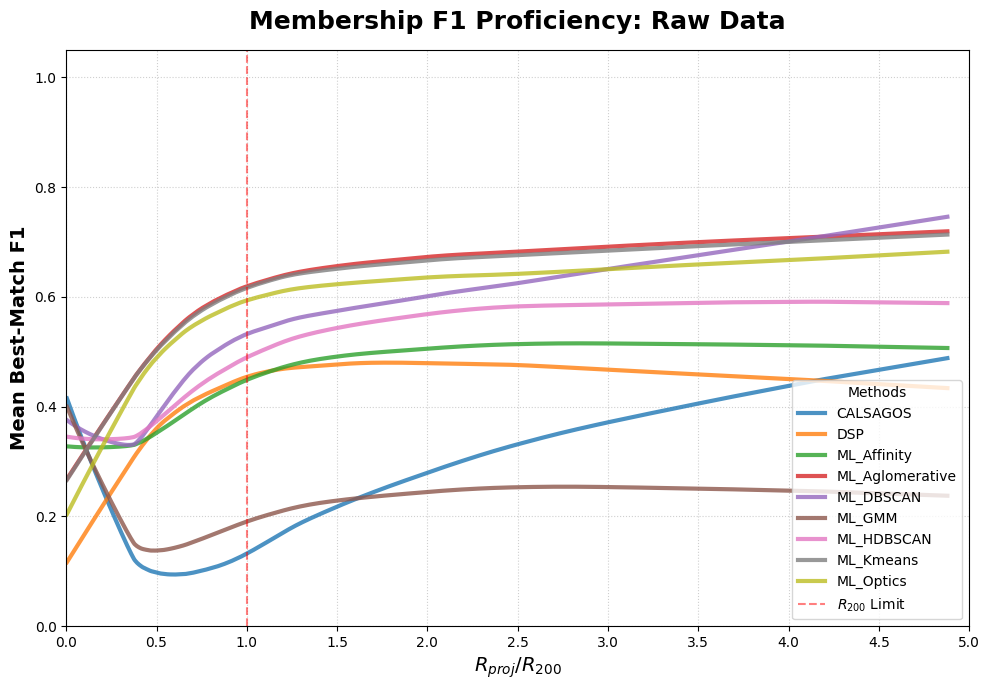

Saved: Images/Radial_Proficiency/Clean_M_F1_Radial.png


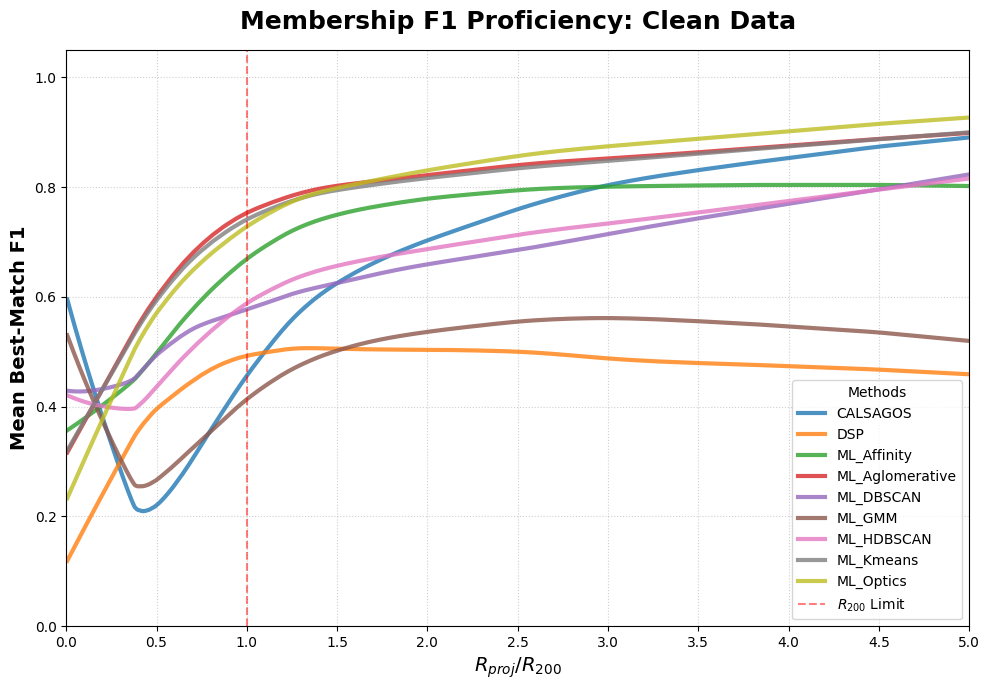

Saved: Images/Radial_Proficiency/SPLUS_M_F1_Radial.png


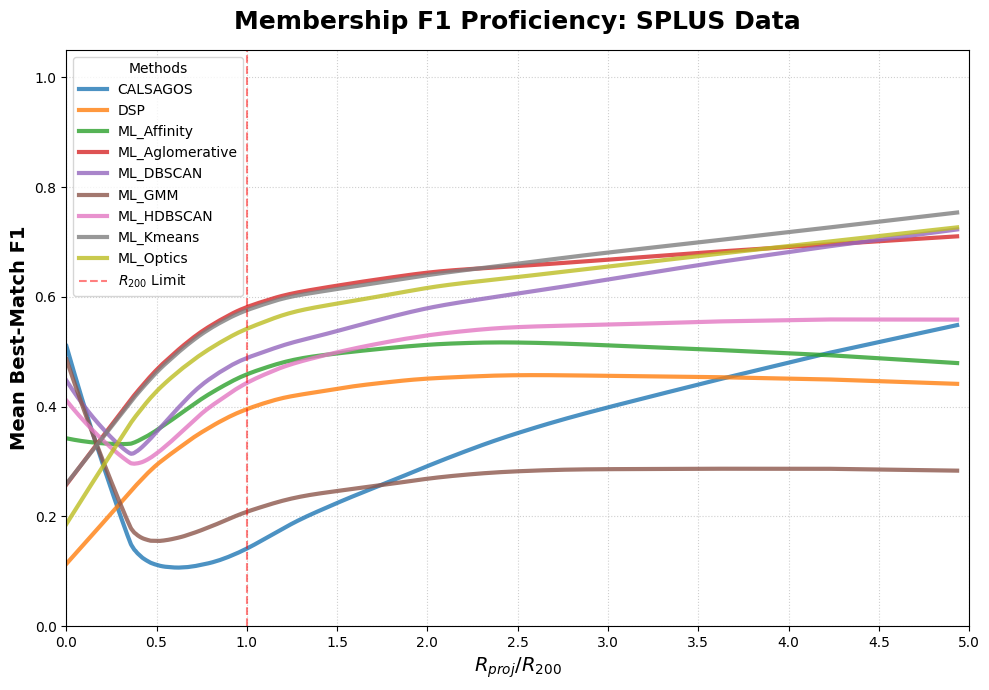

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import numpy as np

keys = ["Raw", "Clean", "SPLUS"]
source_metrics = ["N_F1", "M_F1"]
titles_map = {"N_F1": "Neighborhood F1", "M_F1": "Membership F1"}

# --- DIRECTORY SETUP ---
save_base = "Images/Radial_Proficiency"
os.makedirs(save_base, exist_ok=True)

for metric in source_metrics:
    for key in keys:
        # 1. Create a fresh figure for each combination
        plt.figure(figsize=(10, 7))
        ax = plt.gca()
        
        file_path = f"Metrics/Radial_Halo_Proficiency/{key}/{metric}_no_noise_radial.pkl"
        
        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue
            
        with open(file_path, "rb") as f:
            data = pickle.load(f)
            
        # 2. PLOT DATA
        # We sort methods to keep legend colors consistent
        for method in sorted(data.keys()):
            r_vals = data[method]["r"]
            f1_vals = data[method]["f1"]

            if len(r_vals) < 2: continue # Safety check for Lowess

            sns.regplot(x=r_vals, y=f1_vals, scatter=False, lowess=True, 
                        ax=ax, label=method, line_kws={"linewidth": 3, "alpha": 0.8})

        # --- X-AXIS TICK MARKING ---
        # Set ticks every 0.5 from 0 to 5.0
        x_ticks = np.arange(0, 5.5, 0.5)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([f"{val:.1f}" for val in x_ticks], fontsize=10)
        
        # --- STYLING ---
        ax.set_title(f"{titles_map[metric]} Proficiency: {key} Data", fontsize=18, fontweight='bold', pad=15)
        ax.set_ylabel("Mean Best-Match F1", fontsize=14, fontweight='bold')
        ax.set_xlabel(r"$R_{proj} / R_{200}$", fontsize=14, fontweight='bold')
        
        ax.set_ylim(0, 1.05) # Slight headroom
        ax.set_xlim(0, 5.0)
        
        # Mark R200 boundary
        ax.axvline(1.0, color='red', linestyle='--', alpha=0.5, label="$R_{200}$ Limit")
        ax.grid(True, which='both', linestyle=':', alpha=0.6)
        
        # Place legend inside or outside depending on preference
        ax.legend(loc='best', fontsize=10, title="Methods", frameon=True)

        # --- SAVE INDIVIDUALLY ---
        safe_metric = metric.replace("/", "_")
        filename = f"{save_base}/{key}_{safe_metric}_Radial.png"
        
        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")
        plt.show() # Display each as they generate 

In [28]:
import numpy as np
import pickle
import os

keys = ["Raw", "Clean", "SPLUS"]
metric = "M_F1" # Checking one is enough for spatial distribution

print(f"{'Regime':<10} | {'Max R/R200':<12} | {'Total Halos':<12} | {'Halos > 5R200':<15} | {'% Outliers'}")
print("-" * 80)

for key in keys:
    file_path = f"Metrics/Radial_Halo_Proficiency/{key}/{metric}_no_noise_radial.pkl"
    if not os.path.exists(file_path): continue
    
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    
    # Use one method to represent the physical distribution (all methods use the same halos)
    # Picking the one with the most points just in case of detection failures
    method = max(data, key=lambda m: len(data[m]["r"]))
    r_vals = data[method]["r"]
    
    max_r = np.max(r_vals)
    total = len(r_vals)
    above_5 = np.sum(r_vals > 5.0)
    pct_outliers = (above_5 / total) * 100
    
    print(f"{key:<10} | {max_r:<12.2f} | {total:<12} | {above_5:<15} | {pct_outliers:.2f}%")

Regime     | Max R/R200   | Total Halos  | Halos > 5R200   | % Outliers
--------------------------------------------------------------------------------
Raw        | 279.60       | 4562         | 4110            | 90.09%
Clean      | 304.02       | 4562         | 4009            | 87.88%
SPLUS      | 282.69       | 3552         | 3128            | 88.06%


In [33]:
# Re-run the diagnostic with the fixed function
keys = ["Raw", "Clean", "SPLUS"]
metric = "M_F1"

print(f"{'Regime':<10} | {'Max R/R200':<12} | {'Mean R/R200':<12} | {'Halos > 5R200'}")
print("-" * 65)

for key in keys:
    # We need to re-calculate a small sample or use the loop logic to check
    # Let's just check the first 20 clusters in each regime for this diagnostic
    all_r = []
    for i in range(min(20, len(cluster_samples[key]))):
        df = cluster_samples[key][i]
        r = get_halo_radial_distances(df)
        all_r.extend(r)
    
    all_r = np.array(all_r)
    print(f"{key:<10} | {np.max(all_r):<12.2f} | {np.mean(all_r):<12.2f} | {np.sum(all_r > 5.0)}")

Regime     | Max R/R200   | Mean R/R200  | Halos > 5R200
-----------------------------------------------------------------
Raw        | 2.05         | 0.56         | 0
Clean      | 2.07         | 0.57         | 0
SPLUS      | 2.08         | 0.53         | 0


In [10]:
import numpy as np
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
sample_df = cluster_samples["Raw"][0].copy()

# --- PREP DATA ---
for col in ["RA", "DEC", "z_app", "log(m_200)"]:
    sample_df[col] = pd.to_numeric(sample_df[col], errors='coerce')

ra_clus = biweight_location(sample_df["RA"].values)
dec_clus = biweight_location(sample_df["DEC"].values)
z_clus = biweight_location(sample_df["z_app"].values)
logM200 = sample_df["log(m_200)"].iloc[0]

# --- METHOD 1: YOUR FUNCTIONS (Mpc based) ---
r200_mpc = au.get_r_200(logM200, z_clus)
# Get the furthest galaxy in the sample
max_ra_gal = sample_df.loc[((sample_df["RA"] - ra_clus)**2 + 
                            (sample_df["DEC"] - dec_clus)**2).idxmax()]

x_mpc, y_mpc = au.gal_Mpc_coords(max_ra_gal["RA"], max_ra_gal["DEC"], 
                                z_clus, ra_clus, dec_clus)
r_proj_mpc = np.sqrt(x_mpc**2 + y_mpc**2)
ratio_method_1 = r_proj_mpc / r200_mpc

# --- METHOD 2: MANUAL ANGULAR CHECK (Arcmin based) ---
d_a = cosmo.angular_diameter_distance(z_clus).value # Mpc
r200_arcmin = np.degrees(r200_mpc / d_a) * 60

dra = (max_ra_gal["RA"] - ra_clus) * np.cos(np.radians(dec_clus))
ddec = (max_ra_gal["DEC"] - dec_clus)
max_ang_sep_arcmin = np.sqrt(dra**2 + ddec**2) * 60
ratio_method_2 = max_ang_sep_arcmin / r200_arcmin

print(f"--- COMPARISON RESULTS ---")
print(f"Method 1 (Your Functions): {ratio_method_1:.4f}")
print(f"Method 2 (Manual Angular): {ratio_method_2:.4f}")
print(f"Difference:               {abs(ratio_method_1 - ratio_method_2):.2e}")

--- COMPARISON RESULTS ---
Method 1 (Your Functions): 2.5242
Method 2 (Manual Angular): 2.5240
Difference:               2.36e-04


In [15]:
import numpy as np
import pickle
import pandas as pd
import os

# --- CONFIGURATION ---
keys = ["Raw", "Clean", "SPLUS"]
method_stats = []

for key in keys:
    has_noise = (key != "Clean")
    m_path = f"Metrics/M_F1/{key}/results.pkl" 
    
    if not os.path.exists(m_path):
        print(f"Skipping: {m_path} not found.")
        continue
        
    with open(m_path, "rb") as f: 
        m_data = pickle.load(f)

    for method, halos_dict in m_data.items():
        for h_id, f1_matrix_list in halos_dict.items():
            for f1_mat in f1_matrix_list:
                f1_arr = np.array(f1_mat)
                f1_real = f1_arr[1:, :] if has_noise else f1_arr
                
                n_true = f1_real.shape[0]
                n_pred = f1_real.shape[1]
                
                ratio = n_pred / n_true if n_true > 0 else 0
                
                method_stats.append({
                    "Method": method,
                    "Key": key,
                    "Frag_Ratio": ratio
                })

df_frag = pd.DataFrame(method_stats)
df_frag.to_csv("fragmentation_data_summary.csv", index=False)

TypeError: customize_axes() got an unexpected keyword argument 'color'

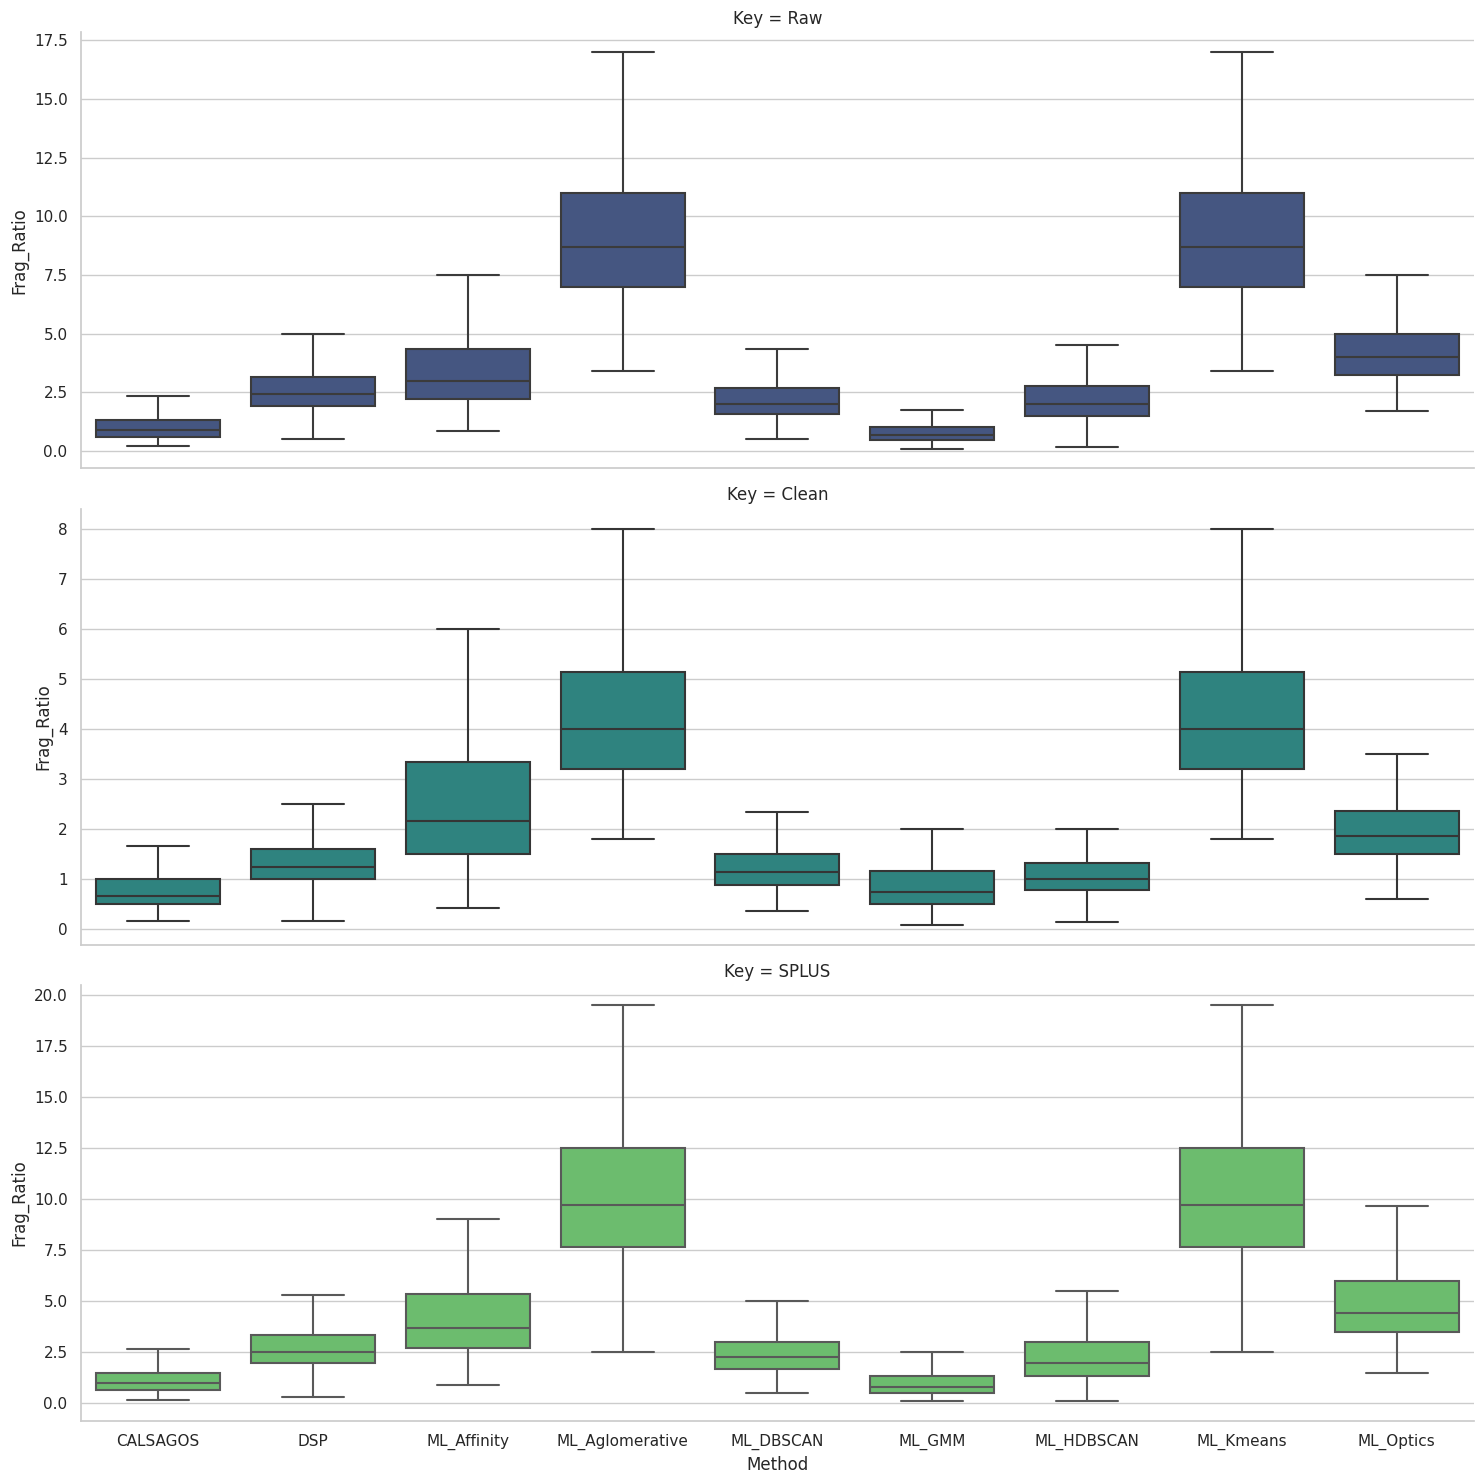

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data
df_frag = pd.read_csv("fragmentation_data_summary.csv")

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a FacetGrid: one row per Key (Regime)
# height and aspect control the size of individual subplots
g = sns.FacetGrid(df_frag, row="Key", hue="Key", palette="viridis", 
                  height=5, aspect=3, sharey=False)

# Map the boxplot to the grid
g.map(sns.boxplot, "Method", "Frag_Ratio", order=sorted(df_frag['Method'].unique()), 
      showfliers=False, linewidth=1.5)

# --- Individual Axis Customization ---
def customize_axes(ax):
    # Fixed reference lines
    ax.axhline(1.0, color='red', linestyle='--', linewidth=2, label="Ideal (1:1)")
    ax.axhline(0.5, color='black', linestyle=':', alpha=0.5, label="Under-seg")
    
    # Expand Y-axis to prevent cutting
    # Using 3.0 to catch higher fragmentation, adjust to 5.0 if needed
    ax.set_ylim(0, 3.5) 
    ax.set_yticks(np.arange(0, 3.6, 0.5))
    
    # Formatting
    ax.set_ylabel("Ratio ($N_{Pred} / N_{True}$)", fontsize=12)
    ax.tick_params(axis='x', rotation=35)

g.map(customize_axes)

# Adjust titles for each subplot
g.set_titles(row_template="{row_name} Regime", size=16, weight='bold')

# Global formatting
plt.subplots_adjust(hspace=0.4, top=0.92)
g.fig.suptitle("Fragmentation Profile per Dataset Regimen", fontsize=22, fontweight='bold')

plt.savefig("fragmentation_individual_regimes.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import pickle
import os

# --- CONFIGURATION ---
keys = ["Raw", "Clean", "SPLUS"]
profiling_name = "Substructure_Proportions"

for key in keys:
    has_noise = (key != "Clean")
    # We use Membership results for this as it tracks specific galaxy counts
    m_path = f"Metrics/M_F1/{key}/results.pkl" 
    
    if not os.path.exists(m_path): continue
    with open(m_path, "rb") as f: m_data = pickle.load(f)

    method_sub_data = {}
    for method, halos_dict in m_data.items():
        all_r, all_frag, all_merge = [], [], []
        
        for h_id, f1_matrix_list in halos_dict.items():
            sample_df = cluster_samples[key][h_id]
            r_distances = get_halo_radial_distances(sample_df) # Using our RA/DEC function
            
            # Average over 10 executions
            frag_per_halo_execs = []
            
            for f1_mat in f1_matrix_list:
                f1_arr = np.array(f1_mat)
                f1_real = f1_arr[1:, :] if has_noise else f1_arr
                
                # Fragmentation: Count non-zero predicted clusters per true halo
                # We use a threshold (e.g., F1 > 0.05) to ignore tiny random overlaps
                frag_counts = np.sum(f1_real > 0.1, axis=1)
                frag_per_halo_execs.append(frag_counts)
            
            # Mean across 10 runs
            mean_frag = np.mean(frag_per_halo_execs, axis=0)
            
            if len(r_distances) == len(mean_frag):
                all_r.extend(r_distances)
                all_frag.extend(mean_frag)

        method_sub_data[method] = {"r": np.array(all_r), "frag": np.array(all_frag)}

    # Save Results
    save_dir = f"Metrics/{profiling_name}/{key}"
    os.makedirs(save_dir, exist_ok=True)
    with open(f"{save_dir}/fragmentation_radial.pkl", "wb") as f:
        pickle.dump(method_sub_data, f)

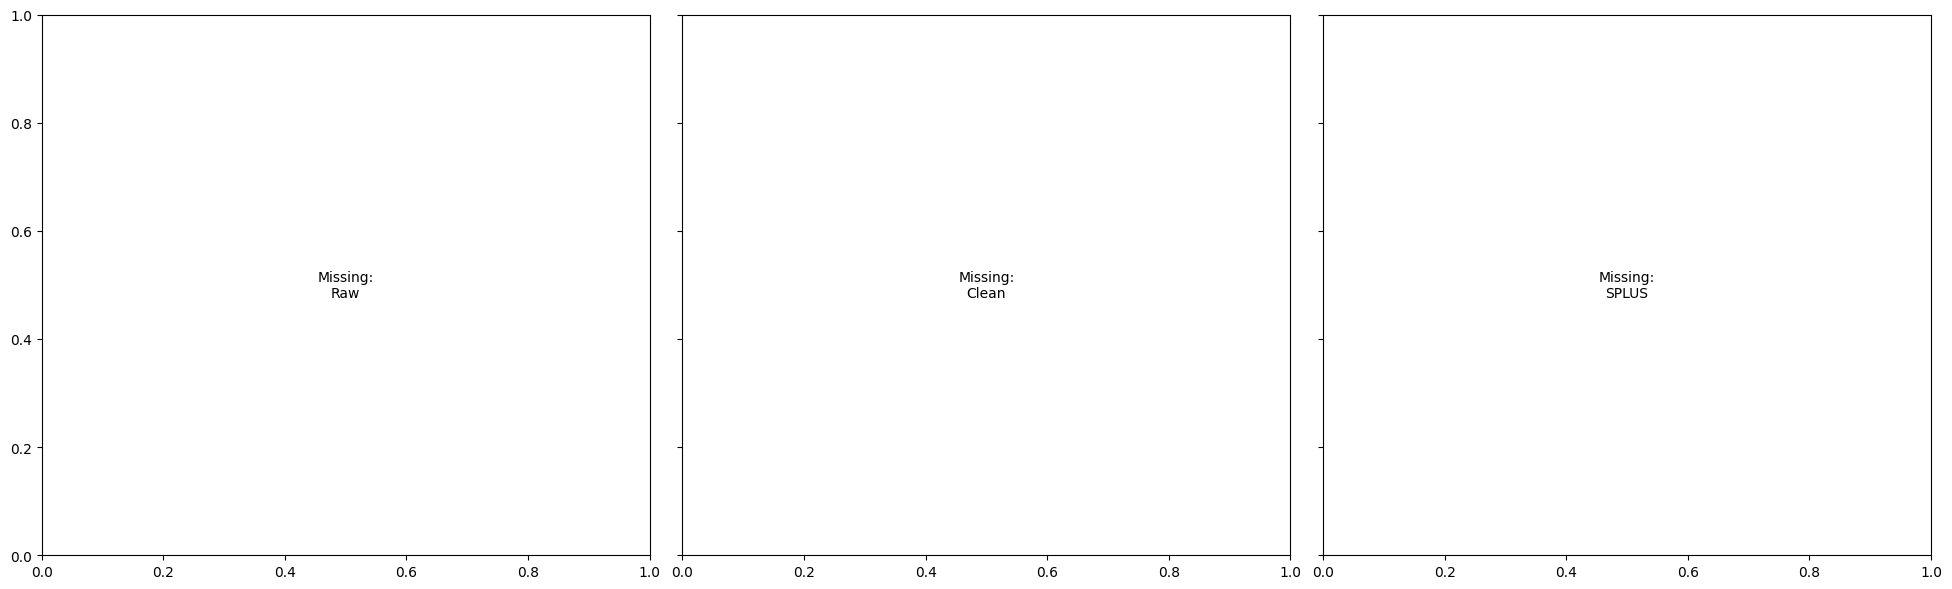

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os

# --- CONFIGURATION ---
keys = ["Raw", "Clean", "SPLUS"]
profiling_name = "Substructure_Proportions"
# We only have one metric source (M_F1) for this specific substructure calculation
# but we maintain the 1x3 or 2x3 layout for consistency.

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True, sharex=True)

for col_idx, key in enumerate(keys):
    ax = axes[col_idx]
    file_path = f"Metrics/{profiling_name}/{key}/fragmentation_radial.pkl"
    
    if not os.path.exists(file_path):
        ax.text(0.5, 0.5, f"Missing:\n{key}", ha='center', va='center')
        continue
        
    with open(file_path, "rb") as f:
        data = pickle.load(f)
        
    # Plot each method's degradation/splitting curve
    for method in sorted(data.keys()):
        r_vals = data[method]["r"]
        frag_vals = data[method]["frag"]
        
        if len(r_vals) < 10: continue
        
        # LOWESS helps average out the 'wild differences' between 700 clusters
        sns.regplot(x=r_vals, y=frag_vals, scatter=False, lowess=True, 
                    ax=ax, label=method, line_kws={"linewidth": 2.5, "alpha": 0.8})

    # --- STYLING ---
    ax.set_title(f"Dataset: {key}", fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel(r"Projected Radius ($R_{proj} / R_{200}$)", fontsize=14)
    
    if col_idx == 0:
        ax.set_ylabel("Fragmentation Ratio\n(Pred Clusters per True Halo)", fontsize=14, fontweight='bold')
    
    # Physical reference lines
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label="Ideal (1:1)")
    ax.axvline(1.0, color='black', linestyle=':', alpha=0.4, label="$R_{200}$")
    
    ax.set_xlim(0, 1.5)
    ax.set_ylim(0.5, 3.5) # Fragmentation usually stays between 1 and 3
    ax.grid(True, linestyle='--', alpha=0.3)
    
    if col_idx == 2:
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Algorithms", fontsize=10)

plt.tight_layout()
plt.subplots_adjust(right=0.88)
plt.savefig("Images/Radial_Fragmentation_Profile.png", dpi=300, bbox_inches='tight')
plt.show()